In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [14]:
base = "C:/Users/monke/Downloads/OneDrive_2026-04-09/Agriculture Data"

# TEST
df_test_b1 = pd.read_csv(f"{base}/Bilinear Tables/TestB_10_04_24.csv")
df_test_c1 = pd.read_csv(f"{base}/Cubic Tables/TestC_10_04_24.csv")
df_test_n1 = pd.read_csv(f"{base}/Nearest Tables/TestN_10_04_24.csv")

# df_test_b2 = pd.read_csv(f"{base}/Bilinear Tables/TestB_10_11_24.csv")
# df_test_c2 = pd.read_csv(f"{base}/Cubic Tables/TestC_10_11_24.csv")
# df_test_n2 = pd.read_csv(f"{base}/Nearest Tables/TestN_10_11_24.csv")

df_test_b3 = pd.read_csv(f"{base}/Bilinear Tables/TestB_10_18_24.csv")
df_test_c3 = pd.read_csv(f"{base}/Cubic Tables/TestC_10_18_24.csv")
df_test_n3 = pd.read_csv(f"{base}/Nearest Tables/TestN_10_18_24.csv")

# df_test_b4 = pd.read_csv(f"{base}/Bilinear Tables/TestB_11_08_24.csv")
# df_test_c4 = pd.read_csv(f"{base}/Cubic Tables/TestC_11_08_24.csv")
# df_test_n4 = pd.read_csv(f"{base}/Nearest Tables/TestN_11_08_24.csv")

# df_test_b5 = pd.read_csv(f"{base}/Bilinear Tables/TestB_11_15_24.csv")
# df_test_c5 = pd.read_csv(f"{base}/Cubic Tables/TestC_11_15_24.csv")
# df_test_n5 = pd.read_csv(f"{base}/Nearest Tables/TestN_11_15_24.csv")


# TRAIN
df_train_b1 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_10_04_24.csv")
df_train_c1 = pd.read_csv(f"{base}/Cubic Tables/TrainC_10_04_24.csv")
df_train_n1 = pd.read_csv(f"{base}/Nearest Tables/TrainN_10_04_24.csv")

# df_train_b2 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_10_11_24.csv")
# df_train_c2 = pd.read_csv(f"{base}/Cubic Tables/TrainC_10_11_24.csv")
# df_train_n2 = pd.read_csv(f"{base}/Nearest Tables/TrainN_10_11_24.csv")

df_train_b3 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_10_18_24.csv")
df_train_c3 = pd.read_csv(f"{base}/Cubic Tables/TrainC_10_18_24.csv")
df_train_n3 = pd.read_csv(f"{base}/Nearest Tables/TrainN_10_18_24.csv")

# df_train_b4 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_11_08_24.csv")
# df_train_c4 = pd.read_csv(f"{base}/Cubic Tables/TrainC_11_08_24.csv")
# df_train_n4 = pd.read_csv(f"{base}/Nearest Tables/TrainN_11_08_24.csv")

# df_train_b5 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_11_15_24.csv")
# df_train_c5 = pd.read_csv(f"{base}/Cubic Tables/TrainC_11_15_24.csv")
# df_train_n5 = pd.read_csv(f"{base}/Nearest Tables/TrainN_11_15_24.csv")

In [16]:
test_nearest = []
test_bilinear = []
test_cubic = []

train_nearest = []
train_bilinear = []
train_cubic = []

for var_name, var_value in list(globals().items()):
    if isinstance(var_value, pd.DataFrame):
        if var_name.startswith('df_test_'):
            if var_name[-2] == 'n':
                test_nearest.append(var_value)
            elif var_name[-2] == 'b':
                test_bilinear.append(var_value)
            elif var_name[-2] == 'c':
                test_cubic.append(var_value)

        elif var_name.startswith('df_train_'):
            if var_name[-2] == 'n':
                train_nearest.append(var_value)
            elif var_name[-2] == 'b':
                train_bilinear.append(var_value)
            elif var_name[-2] == 'c':
                train_cubic.append(var_value)

print(f"Nearest  — Train: {len(train_nearest)}, Test: {len(test_nearest)}")
print(f"Bilinear — Train: {len(train_bilinear)}, Test: {len(test_bilinear)}")
print(f"Cubic    — Train: {len(train_cubic)}, Test: {len(test_cubic)}")

Nearest  — Train: 2, Test: 2
Bilinear — Train: 2, Test: 2
Cubic    — Train: 2, Test: 2


In [18]:


# -----------------------------------------------
# 1. Features, target, models, resamples
# -----------------------------------------------
features = ['X', 'Y', 'L_NDVI', 'Band1', 'Band2', 'Band3', 'Band4', 'Band5', 'Band6', 'Band7', 
            'AEROSOL_Band_1', 'PIXEL_Band_1', 'RADSAT_Band_1']
target = 'UAV_NDVI'

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':          XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

resamples = {
    'nearest':  (train_nearest,  test_nearest),
    'bilinear': (train_bilinear, test_bilinear),
    'cubic':    (train_cubic,    test_cubic),
}

# -----------------------------------------------
# 2. Iterate and store results
# -----------------------------------------------
results = []

for resample_name, (train_list, test_list) in resamples.items():

    train_df = pd.concat(train_list, ignore_index=True)
    test_df  = pd.concat(test_list,  ignore_index=True)

    X_train = train_df[features]
    y_train = train_df[target]
    X_test  = test_df[features]
    y_test  = test_df[target]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2   = r2_score(y_test, preds)

        results.append({
            'Resample': resample_name,
            'Model':    model_name,
            'RMSE':     round(rmse, 4),
            'R2':       round(r2,   4),
        })
        print(f"{resample_name} | {model_name} -> RMSE: {rmse:.4f} | R²: {r2:.4f}")

nearest | LinearRegression -> RMSE: 0.0642 | R²: 0.0202
nearest | RandomForest -> RMSE: 0.0751 | R²: -0.3421
nearest | XGBoost -> RMSE: 0.0950 | R²: -1.1467
nearest | GradientBoosting -> RMSE: 0.0649 | R²: -0.0015
bilinear | LinearRegression -> RMSE: 0.0639 | R²: 0.0296
bilinear | RandomForest -> RMSE: 0.0750 | R²: -0.3360
bilinear | XGBoost -> RMSE: 0.0887 | R²: -0.8708
bilinear | GradientBoosting -> RMSE: 0.0638 | R²: 0.0317
cubic | LinearRegression -> RMSE: 0.0685 | R²: -0.0254
cubic | RandomForest -> RMSE: 0.0849 | R²: -0.5711
cubic | XGBoost -> RMSE: 0.0704 | R²: -0.0821
cubic | GradientBoosting -> RMSE: 0.0682 | R²: -0.0140


In [19]:
# -----------------------------------------------
# 3. Summary tables
# -----------------------------------------------
results_df = pd.DataFrame(results)

print("\n--- R² ---")
print(results_df.pivot(index='Model', columns='Resample', values='R2'))

print("\n--- RMSE ---")
print(results_df.pivot(index='Model', columns='Resample', values='RMSE'))


--- R² ---
Resample          bilinear   cubic  nearest
Model                                      
GradientBoosting    0.0317 -0.0140  -0.0015
LinearRegression    0.0296 -0.0254   0.0202
RandomForest       -0.3360 -0.5711  -0.3421
XGBoost            -0.8708 -0.0821  -1.1467

--- RMSE ---
Resample          bilinear   cubic  nearest
Model                                      
GradientBoosting    0.0638  0.0682   0.0649
LinearRegression    0.0639  0.0685   0.0642
RandomForest        0.0750  0.0849   0.0751
XGBoost             0.0887  0.0704   0.0950


Scaling doesn't help results

In [22]:
from sklearn.preprocessing import StandardScaler

train_df = pd.concat(train_cubic, ignore_index=True)
test_df  = pd.concat(test_cubic,  ignore_index=True)

X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]
y_test  = test_df[target]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
preds = lr.predict(X_test_sc)

print(f"R²:   {r2_score(y_test, preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.4f}")

R²:   -0.0254
RMSE: 0.0685


Testing Combined without (X,Y)

In [ ]:
# Combine all train dataframes
train_df = pd.concat(train_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

# Define features
features = ['L_NDVI', 'Band1', 'Band2', 'Band3', 'Band4', 'Band5', 'Band6', 'Band7', 'AEROSOL_Band_1', 'PIXEL_Band_1', 'RADSAT_Band_1']
target = 'UAV_NDVI'

# Prepare data
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2}")
print(f"MSE: {mse}")

R2 Score: -0.01792999052669786
MSE: 0.004409777772105293


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest -> RMSE: {rf_rmse:.4f} | R²: {rf_r2:.4f}")

Random Forest -> RMSE: 0.0684 | R²: -0.0788


In [7]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost -> RMSE: {xgb_rmse:.4f} | R²: {xgb_r2:.4f}")

XGBoost -> RMSE: 0.0680 | R²: -0.0683


In [8]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print(f"Gradient Boosting -> RMSE: {gb_rmse:.4f} | R²: {gb_r2:.4f}")

Gradient Boosting -> RMSE: 0.0678 | R²: -0.0626


Testing Combined with (X,Y)

In [10]:
# Define features
features = ['X', 'Y', 'L_NDVI', 'Band1', 'Band2', 'Band3', 'Band4', 'Band5', 'Band6', 'Band7', 'AEROSOL_Band_1', 'PIXEL_Band_1', 'RADSAT_Band_1']
target = 'UAV_NDVI'

# Prepare data
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2}")
print(f"MSE: {mse}")

R2 Score: 0.042154137271306014
MSE: 0.004149487129638932


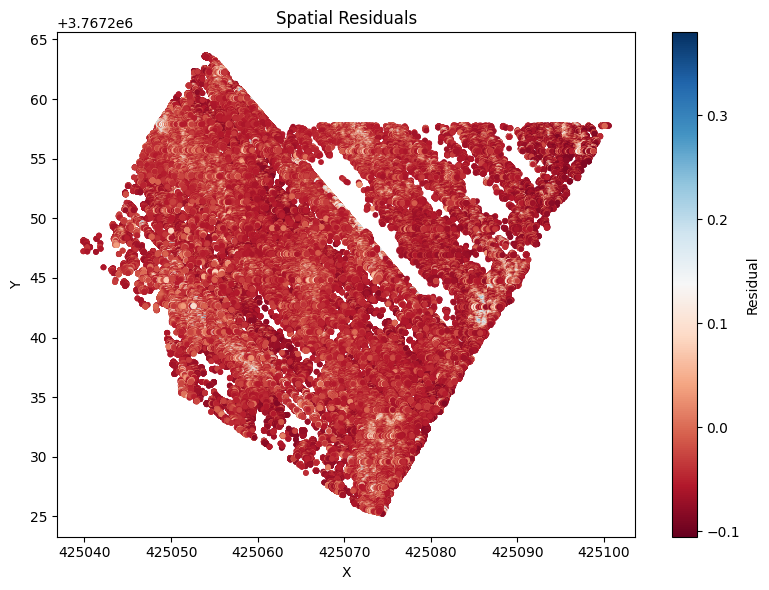

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_test['X'], X_test['Y'], c=y_test - y_pred, cmap='RdBu', s=10)
plt.colorbar(sc, label='Residual')
plt.title('Spatial Residuals')
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()

In [12]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest -> RMSE: {rf_rmse:.4f} | R²: {rf_r2:.4f}")

Random Forest -> RMSE: 0.0739 | R²: -0.2610


In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost -> RMSE: {xgb_rmse:.4f} | R²: {xgb_r2:.4f}")

In [ ]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print(f"Gradient Boosting -> RMSE: {gb_rmse:.4f} | R²: {gb_r2:.4f}")